# Atividade I - Visualização de Dados - Analise Exploratória de Dados


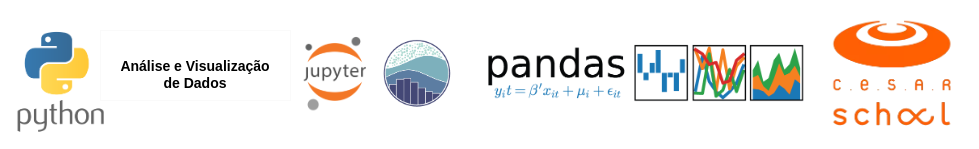

**Nome do Grupo**


*   Lucas Barbosa dos Santos (lbs3@cesar.school)




**OBJETIVO**

O objetivo desta atividade é criar insights, a partir de uma análise exploratória de dados. Para tal, siga os seguintes passos:

1. Escolha um dataset do seu interesse.
2. Faça um entendimento deste conjunto de dados.
3. Realize a limpeza dos dados (*caso aplicável*)
   *   Identifique valores ausentes
   *   Remova e trate linhas duplicadas.
   *   Realize a correção de incosistências e conversão de tipos.
4. Observe outliers e justifique a presença ou remoção destes.
5. Crie visualizações de dados para este dataset. A partir destas, apresente 04 insights a partir dos dados traduzido em visualizações.

Este notebook é apenas um roteiro para envio das atividades, divido nos tópicos. O mesmo pode ser alterado, favor apenas confirmar que todas as visualizações estejam presentes na hora da submissão no **Classroom**. Tente se organizar na estruutra proposta, facilita a correção da sua atividade.


# 1 - Escolha do dataset

Carregue seu dataset.

Pontuação **05 pts.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts

In [ ]:
#Dataset utilizado: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
from google.colab import drive
drive.mount("/content/drive")
file_path = "/content/drive/My Drive/Colab Notebooks"
DataFrame = pd.read_csv(file_path + "/heart.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2 - Entendimento do conjuto de dados

Pontuação **05 pts.**


# **Descrição das Variáveis do Dataset**

O conjunto de dados analisado contém informações clínicas de pacientes e suas condições cardíacas. A seguir, apresentamos uma explicação detalhada de cada variável:

**Idade** (Age): Representa a idade do paciente, expressa em anos.

**Gênero** (Sex): Indica o gênero do paciente, sendo M para masculino (Male) e F para feminino (Female).

**Tipo de Dor no Peito** (ChestPainType): Classifica o tipo de dor torácica relatada pelo paciente, podendo ser:

**-> TA**(Typical Angina) – Angina típica, geralmente causada por isquemia do miocárdio.

**-> ATA** (Atypical Angina) – Angina atípica, cuja origem pode não estar diretamente relacionada ao coração.

**-> NAP** (Non-Anginal Pain) – Dor torácica não anginosa, muitas vezes causada por problemas não cardíacos.

**-> ASY** (Asymptomatic) – Paciente assintomático, ou seja, sem dor torácica.

**Pressão Arterial em Repouso** (RestingBP): Medida da pressão arterial do paciente em repouso, expressa em milímetros de mercúrio (mmHg).

**Colesterol** (Cholesterol): Nível de colesterol sérico do paciente, medido em mg/dL. Valores elevados podem indicar risco para doenças cardiovasculares.

**Glicemia de Jejum**(FastingBS): Indica se o paciente possui nível elevado de glicose no sangue em jejum. A variável é categorizada da seguinte forma:

**-> 1**  – Glicemia de jejum superior a 120 mg/dL (indicando possível diabetes ou resistência à insulina).

**-> 0** – Glicemia de jejum normal.

**Eletrocardiograma em Repouso** (RestingECG): Representa os resultados do exame de eletrocardiograma realizado em repouso, podendo ser:

**-> Normal** – Sem alterações eletrocardiográficas.

**-> ST** – Presença de anormalidades na onda ST-T (inversões da onda T e/ou elevação ou depressão do segmento ST > 0.05 mV), que podem indicar isquemia.

**-> LVH** (Left Ventricular Hypertrophy) – Indícios de hipertrofia ventricular esquerda, de acordo com os critérios de Estes.

**Frequência Cardíaca Máxima** (MaxHR): Indica a maior frequência cardíaca atingida pelo paciente durante um teste físico, variando entre 60 e 202 bpm (batimentos por minuto).

**Angina Induzida por Exercício** (ExerciseAngina): Indica se o paciente apresentou dor no peito durante o esforço físico:

**-> Y** (Yes) – Sim, houve angina induzida pelo exercício.

**-> N** (No) – Não houve angina durante o exercício.

**Oldpeak** (Depressão de ST): Mede a depressão do segmento ST, um parâmetro importante para avaliar a redução do fluxo sanguíneo para o coração. Quanto maior o valor, maior a probabilidade de isquemia cardíaca.

**Inclinação do Segmento ST** (ST_Slope): Representa a inclinação do segmento ST durante o teste de esforço, podendo ser:

**-> Up** (Upsloping) – Inclinação ascendente, geralmente associada a uma resposta normal ao exercício.

**-> Flat** (Flat) – Linha plana, podendo indicar risco moderado a alto de doença cardíaca.

**-> Down** (Downsloping) – Inclinação descendente, frequentemente associada a isquemia severa.

**Doença Cardíaca** (HeartDisease): Variável que indica a presença ou ausência de doença cardíaca:

**-> 1** – Paciente diagnosticado com doença cardíaca.

**-> 0** – Paciente sem diagnóstico de doença cardíaca (normal).

In [ ]:
DataFrame.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
DataFrame.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
DataFrame.info()
#Não apresenta Dados Nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
DataFrame.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# 3 - Limpeza dos Dados

Dica: se aplicável, executar as etapas do [Capítulo 7](https://wesmckinney.com/book/data-cleaning) do livro Python for Data Analysis.

Pontuação **10 pts.**, *caso aplicável*.


In [ ]:
DataFrame.duplicated().sum()

0

# 4 - Análise de Outliers

Pontuação: **10 pts.**.

Justifique a presença ou remoção dos outliers, das colunas correspondnetes.

Ex: no dataset do titanic podemos encontrar instâncias de dados com uma idade de 0.9. Isso faria sentido? Sim ou não?  Caso fosse encontrado uma instância com registro de 142 para idade, faria sentido? Torna-se importante analisar algumas colunas do conjunto.


<Axes: ylabel='RestingBP'>

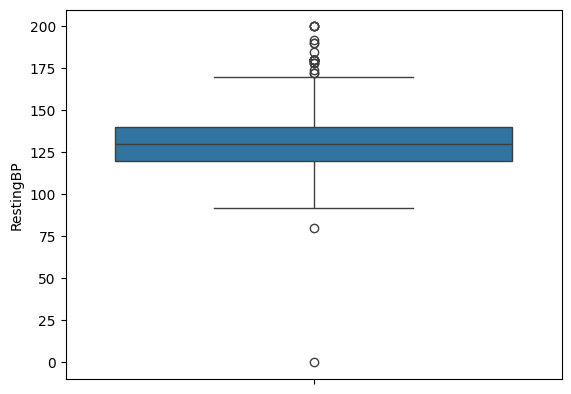

In [ ]:
# O Intervalo  normal de Pressão Arterial em Repouso de um ser humano é [60:250], nunca pode chegar a 0
sns.boxplot(data=DataFrame, y = "RestingBP")

In [ ]:
DataFrame.loc[(DataFrame["RestingBP"] < 60) |( DataFrame["RestingBP"] > 250)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [ ]:
mediana = sts.median(DataFrame["RestingBP"])
mediana

130.0

In [ ]:
DataFrame.loc[(DataFrame["RestingBP"] < 60) |( DataFrame["RestingBP"] > 250), "RestingBP"] = mediana
DataFrame.loc[(DataFrame["RestingBP"] < 60) |( DataFrame["RestingBP"] > 250)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


<Axes: ylabel='Cholesterol'>

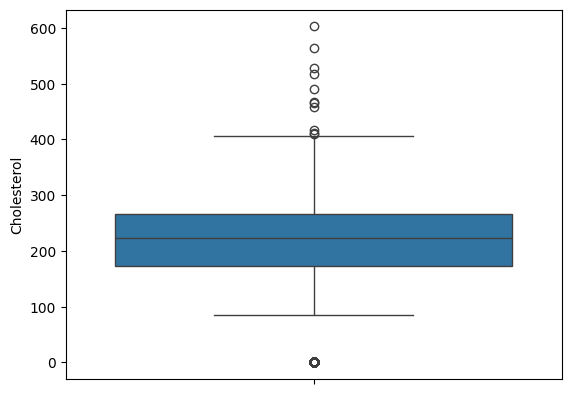

In [ ]:
# O Intervalo Normal de Colesterol de um ser humano é [50:650], nunca pode chegar a zero
sns.boxplot(data=DataFrame, y = "Cholesterol")

In [ ]:
DataFrame.loc[(DataFrame["Cholesterol"] < 50) |( DataFrame["Cholesterol"] > 650)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [ ]:
mediana2 = sts.median(DataFrame["Cholesterol"])
mediana2

223.0

In [ ]:
DataFrame.loc[(DataFrame["Cholesterol"] < 50) |( DataFrame["Cholesterol"] > 650),"Cholesterol"] = mediana2
DataFrame.loc[(DataFrame["Cholesterol"] < 50) |( DataFrame["Cholesterol"] > 650)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


# 5 - Visualizações

Pontuação: 70-80 pts.

Crie insights a partir do seu conjunto de dados.

Neste item será considerando a presençã ou ausência de elementos gráficos que ajude a interpretação da visualização.

In [ ]:
contagem = DataFrame['HeartDisease'].value_counts()
contagem

,count
HeartDisease,
1,508
0,410


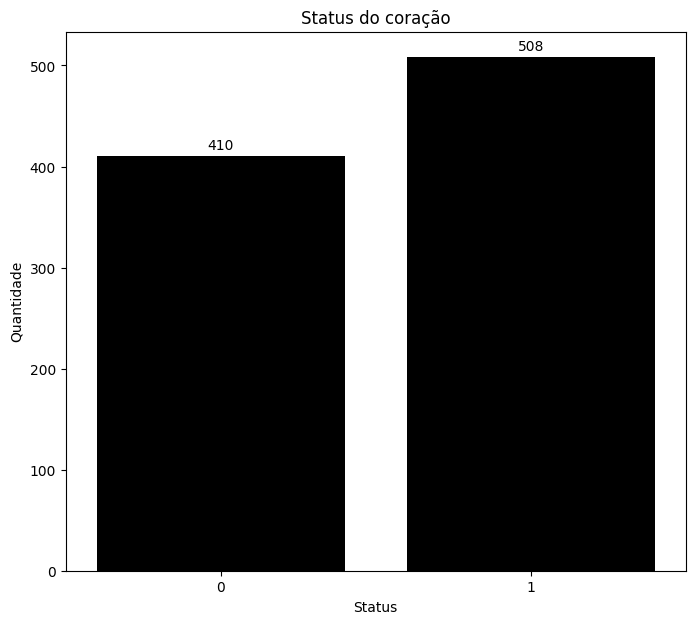

In [ ]:
plt.figure(figsize=(8, 7))
ax = sns.barplot(x=contagem.index, y=contagem.values, color = "black")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Status do coração')
plt.xlabel('Status')
plt.ylabel('Quantidade')
plt.show()

## Insight 1 - Pessoas acima de 54 anos apresentam maior prevalência de doenças cardíacas.

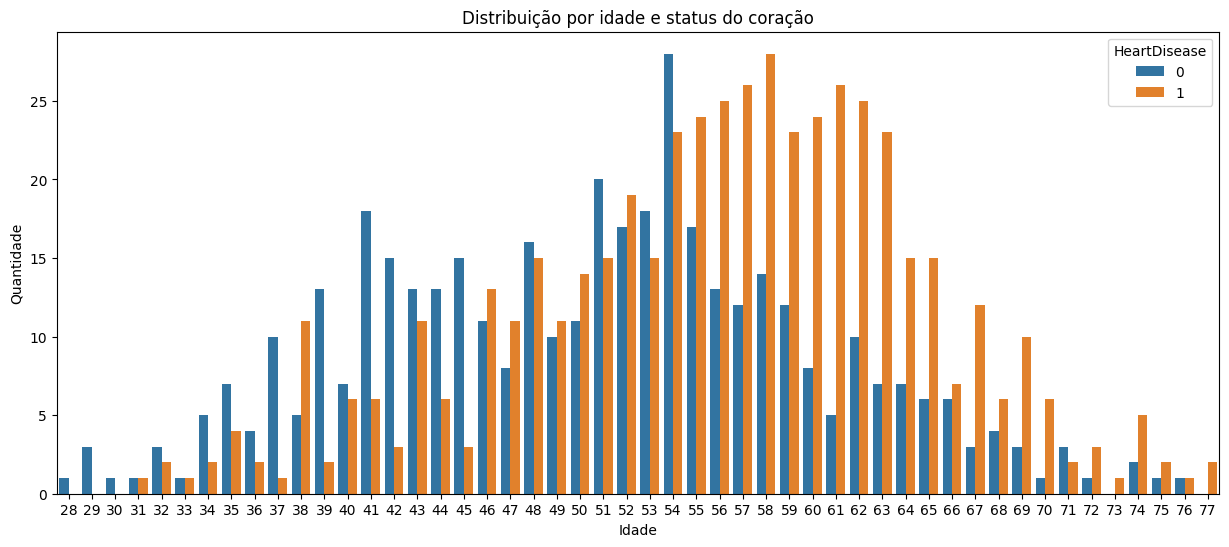

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(x = 'Age', hue = 'HeartDisease', data = DataFrame)
plt.title('Distribuição por idade e status do coração')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.show()

## Insight 2 - A maioria dos pacientes com doença cardiáca eram assintomáticos quanto à dor no peito

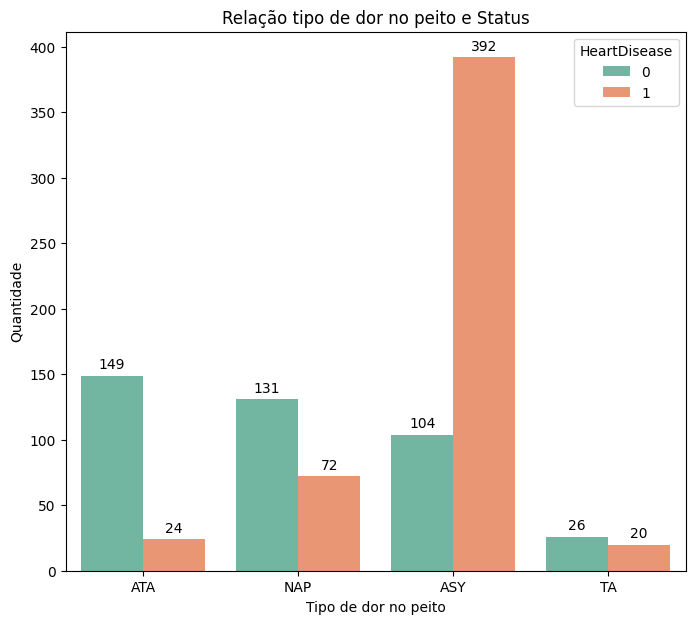

In [ ]:
paleta = sns.color_palette("Set2", 2)
plt.figure(figsize=(8, 7))
ax = sns.countplot(x='ChestPainType', hue='HeartDisease', data=DataFrame, palette=paleta)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Relação tipo de dor no peito e Status')
plt.xlabel('Tipo de dor no peito')
plt.ylabel('Quantidade')
plt.show()

## Insight 3 - A doença cardíaca é mais predominante em pacientes com frequência cardíaca máxima mais baixa

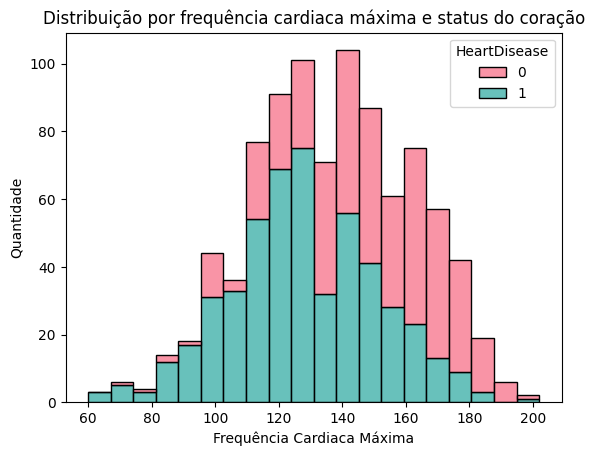

In [ ]:
paleta = sns.color_palette("husl", 2)
sns.histplot(data=DataFrame, x="MaxHR", hue="HeartDisease", multiple= "stack",palette = paleta)
plt.title('Distribuição por frequência cardiaca máxima e status do coração')
plt.xlabel('Frequência Cardiaca Máxima')
plt.ylabel('Quantidade')
plt.show()

## Insight 4 - A maioria dos pacientes com doença cardíaca apresentou dor no peito após exercício

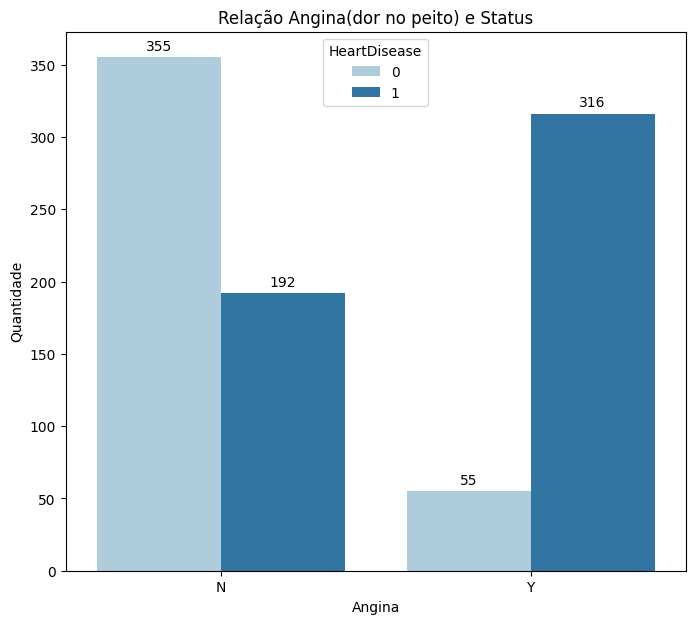

In [ ]:
paleta = sns.color_palette("Paired", 2)
plt.figure(figsize=(8, 7))
ax = sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=DataFrame, palette=paleta)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Relação Angina(dor no peito) e Status')
plt.xlabel('Angina')
plt.ylabel('Quantidade')
plt.show()